In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df.set_index("Order Date", inplace=True)

/tmp/ipykernel_11211/2258186726.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df["Sales"].resample("M").sum()


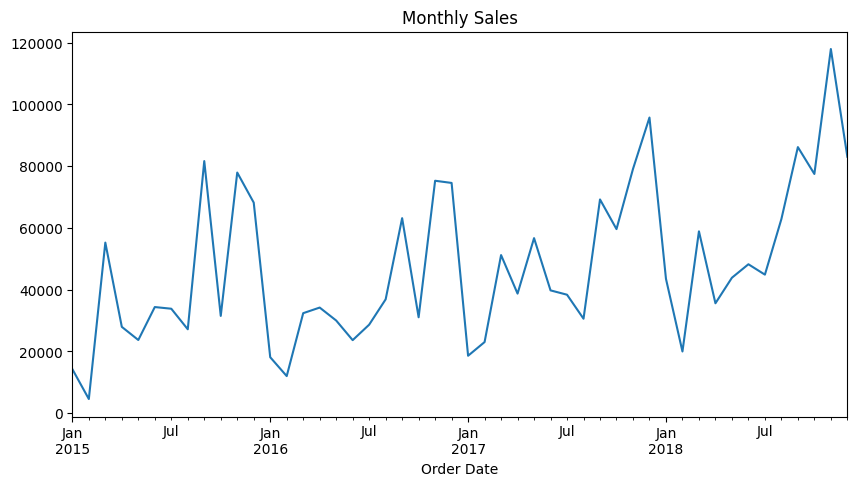

In [6]:
monthly_sales = df["Sales"].resample("M").sum()
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales")
plt.show()

In [7]:
!pip install statsmodels

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales, order=(5,1,0))
model_fit = model.fit()

In [9]:
forecast = model_fit.forecast(steps=12)
forecast

,predicted_mean
2019-01-31,77882.535868
2019-02-28,82080.050386
2019-03-31,78363.673707
2019-04-30,77562.297658
2019-05-31,90178.601085
2019-06-30,84479.482536
2019-07-31,83175.392777
2019-08-31,85201.846397
2019-09-30,82194.773337
2019-10-31,81241.336991


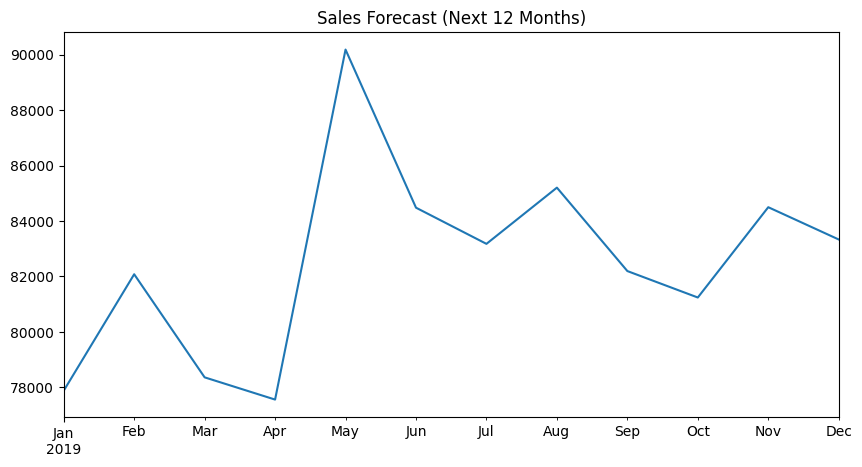

In [10]:
forecast.plot(figsize=(10,5))
plt.title("Sales Forecast (Next 12 Months)")
plt.show()

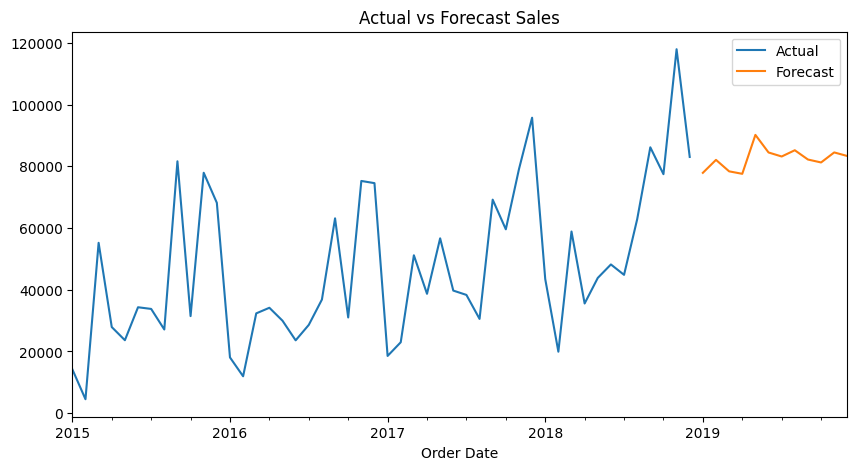

In [11]:
monthly_sales.plot(label="Actual", figsize=(10,5))
forecast.plot(label="Forecast")
plt.legend()
plt.title("Actual vs Forecast Sales")
plt.show()

## 📊 Insights

- Sales show seasonal trends over time  
- Monthly aggregation helps identify patterns clearly  
- The ARIMA model predicts future sales based on historical trends  
- Forecasting can help businesses plan inventory and marketing strategies  